# 03 — Clustering: Segmentasi Pelanggan (K-Means)

Notebook ini mengelompokkan pelanggan ke dalam klaster berdasarkan usia, jumlah order, dan total pengeluaran menggunakan K-Means dari Spark MLlib.

## 1. Setup

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.insert(0, "/home/jovyan/work")

from analysis.spark_session import create_spark_session
spark = create_spark_session("03 - Clustering")

## 2. Baca Fitur Pelanggan dari Processed Zone

In [2]:
BUCKET = "datalake"
df_features = spark.read.csv(f"s3a://{BUCKET}/processed/customer_features/", header=True, inferSchema=True)
df_features.show(5)
print(f"Total baris: {df_features.count()}")

+-----------+-------------+--------+---+------------+-----------+-------------------+-------------+
|customer_id|customer_name|    city|age|total_orders|total_spend|avg_spend_per_order|is_high_value|
+-----------+-------------+--------+---+------------+-----------+-------------------+-------------+
|          1|         Andi|  Malang| 21|           4|    9545000|          2386250.0|            1|
|          2|         Budi|  Blitar| 22|           2|    8000000|          4000000.0|            1|
|          3|        Citra|Surabaya| 20|           2|    8880000|          4440000.0|            1|
|          4|         Dewi|  Kediri| 23|           2|    8000000|          4000000.0|            1|
|          5|          Eko| Jakarta| 25|           3|   12920000|         4306666.67|            1|
+-----------+-------------+--------+---+------------+-----------+-------------------+-------------+
only showing top 5 rows

Total baris: 30


## 3. Jalankan K-Means (k=3)

In [3]:
from analysis.mining.clustering import run_kmeans

df_clustered, model = run_kmeans(
    df_features,
    feature_cols=["age", "total_orders", "total_spend"],
    k=3,
)

df_clustered.select("customer_name", "city", "age", "total_orders", "total_spend", "cluster").show()

+-------------+----------+---+------------+-----------+-------+
|customer_name|      city|age|total_orders|total_spend|cluster|
+-------------+----------+---+------------+-----------+-------+
|         Andi|    Malang| 21|           4|    9545000|      1|
|         Budi|    Blitar| 22|           2|    8000000|      2|
|        Citra|  Surabaya| 20|           2|    8880000|      2|
|         Dewi|    Kediri| 23|           2|    8000000|      2|
|          Eko|   Jakarta| 25|           3|   12920000|      2|
|         Fani|   Bandung| 19|           2|     770000|      0|
|       Gilang|Yogyakarta| 28|           1|     320000|      0|
|         Hana|  Semarang| 24|           1|     450000|      0|
|        Irfan|     Medan| 30|           2|     770000|      0|
|        Julia|  Makassar| 22|           2|    4275000|      0|
|       Krisna|  Surabaya| 27|           3|     275000|      0|
|        Linda|   Jakarta| 31|           2|     152500|      0|
|        Mario|   Bandung| 26|          

## 4. Ringkasan per Klaster

In [4]:
from pyspark.sql import functions as F

df_clustered.groupBy("cluster").agg(
    F.count("customer_id").alias("jumlah_pelanggan"),
    F.round(F.avg("age"), 1).alias("rata_usia"),
    F.round(F.avg("total_orders"), 1).alias("rata_orders"),
    F.round(F.avg("total_spend"), 0).alias("rata_spend"),
).orderBy("cluster").show()

+-------+----------------+---------+-----------+----------+
|cluster|jumlah_pelanggan|rata_usia|rata_orders|rata_spend|
+-------+----------------+---------+-----------+----------+
|      0|              23|     26.4|        2.0|  663065.0|
|      1|               1|     21.0|        4.0| 9545000.0|
|      2|               6|     26.2|        2.3| 9216667.0|
+-------+----------------+---------+-----------+----------+



## 5. Visualisasi Klaster

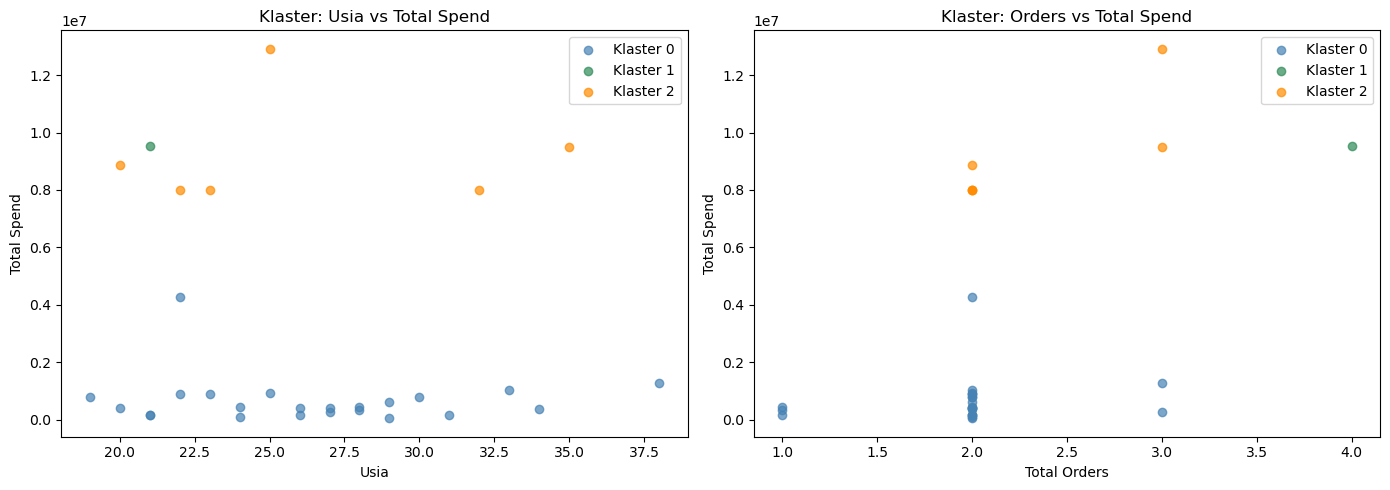

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = df_clustered.toPandas()
colors = {0: "steelblue", 1: "seagreen", 2: "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster_id, group in pdf.groupby("cluster"):
    axes[0].scatter(group["age"], group["total_spend"], label=f"Klaster {cluster_id}", color=colors[cluster_id], alpha=0.7)
axes[0].set_xlabel("Usia")
axes[0].set_ylabel("Total Spend")
axes[0].set_title("Klaster: Usia vs Total Spend")
axes[0].legend()

for cluster_id, group in pdf.groupby("cluster"):
    axes[1].scatter(group["total_orders"], group["total_spend"], label=f"Klaster {cluster_id}", color=colors[cluster_id], alpha=0.7)
axes[1].set_xlabel("Total Orders")
axes[1].set_ylabel("Total Spend")
axes[1].set_title("Klaster: Orders vs Total Spend")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Centroid Klaster

In [6]:
# Ambil centroid dari tahap KMeans dalam pipeline
kmeans_model = model.stages[-1]
for i, center in enumerate(kmeans_model.clusterCenters()):
    print(f"Klaster {i}: {center}")

Klaster 0: [ 0.04526701 -0.23620724 -0.52021142]
Klaster 1: [-1.04114125  3.12795655  1.78221977]
Klaster 2: [4.44089210e-16 3.84135014e-01 1.69710713e+00]


## 7. Simpan Hasil ke MinIO

In [9]:
df_clustered.drop("features").write.mode("overwrite").option("header", True) \
    .csv(f"s3a://{BUCKET}/processed/customer_clusters/")
print("Hasil clustering disimpan ke processed zone.")

Hasil clustering disimpan ke processed zone.
